## Automated Egg Damage Detection Using Deep Learning

**ix. MODEL INFERENCE**

Nama : Muhammad Ali Fikri <br>
Batch : RMT - 053<br>  

**IMPORT LIBRARY**

In [1]:
# Import libraries

import pickle
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

**LOAD MODEL**

In [2]:
#load model
model_comvis_inf = load_model('model_comvis_gc7.keras')

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [3]:
from google.colab import files
uploaded = files.upload()

Saving egg_damaged.jpg to egg_damaged (1).jpg


**ix. MODEL INFERENCE**

In [4]:
#fungsi untuk mempredict image
def prediction(file, img_height=224, img_width=224):
  ## Load an image
  image_inf = tf.keras.utils.load_img(file, target_size=(img_height, img_width))

  ## Rescaling and reshaping image
  x = tf.keras.utils.img_to_array(image_inf)/255
  x = np.expand_dims(x, axis=0)


  ## Predict
  y_pred_inf_proba = model_comvis_inf.predict(x)

 # Convert ke class
  if y_pred_inf_proba[0][0] > 0.5:
      y_pred_class_name = 'not_damaged'
  else:
      y_pred_class_name = 'damaged'

  return image_inf, y_pred_class_name

PREDICT

Dilakukan predict terhadap telur yang rusak (damaged) dan bagus (not damaged)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 984ms/step


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

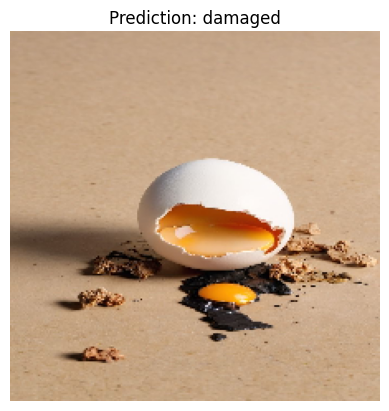

In [5]:
#predict damaged egg
file_path = 'egg_damaged.jpg'

img, pred = prediction(file_path)

import matplotlib.pyplot as plt
plt.imshow(img)
plt.title(f"Prediction: {pred}")
plt.axis('off')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

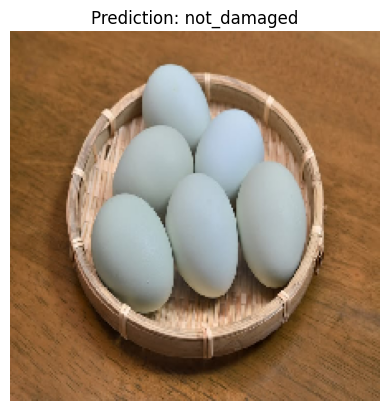

In [6]:
#predict not damaged egg
file_path = 'telur_bebek.jpg'

img, pred = prediction(file_path)

import matplotlib.pyplot as plt
plt.imshow(img)
plt.title(f"Prediction: {pred}")
plt.axis('off')

It was found that the model is still able to predict whether eggs are *damaged* or *undamaged*.  

This suggests that while the model may still be capable of predicting the target, its performance tends to decline—or it becomes less accurate—when tested with a large number of targets.  